In [20]:
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [21]:
def visualize_input(image, ax):
    ax.imshow(image, cmap='gray')
    width, height = image.shape
    thresh = image.max() / 2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(image[x][y]), xy=(y, x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if image[y][x] < thresh else 'black')

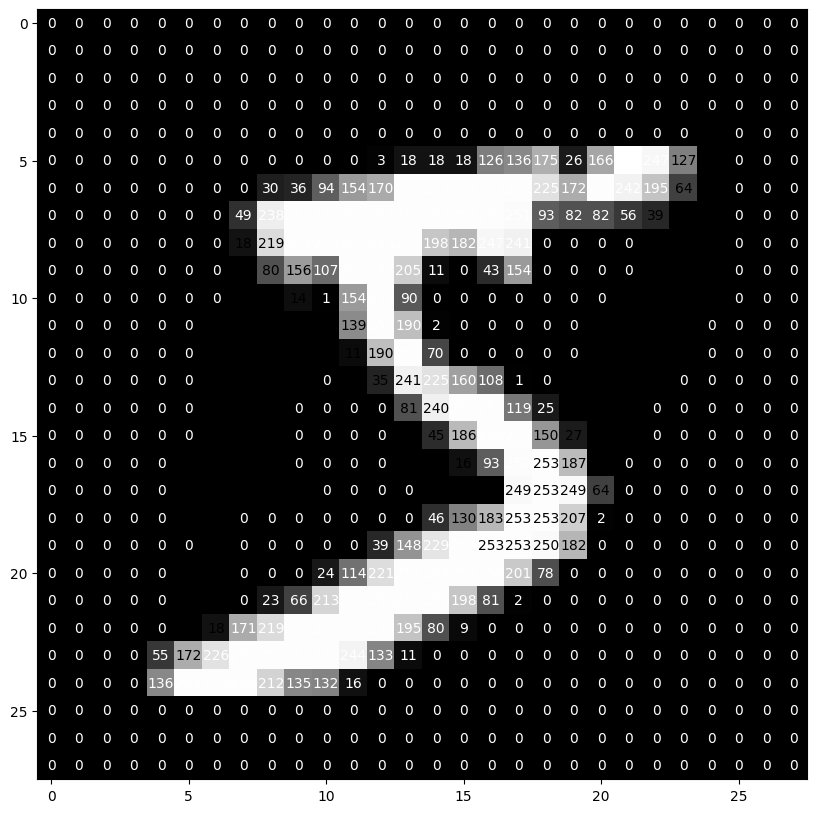

In [22]:
import matplotlib.pyplot as plt
fig =plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
visualize_input(x_train[0], ax)

Text(0.5, 1.0, '[np.uint8(9)]')

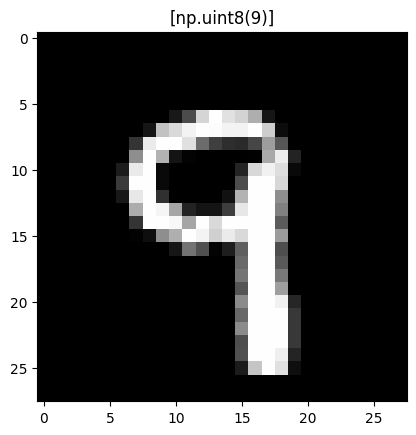

In [23]:
import random
import matplotlib.pyplot as plt
i = random.randint(0,60000)
plt.imshow(x_train[i],cmap='gray')
plt.title([y_train[i]])

In [24]:
import numpy as np
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [25]:
np.unique(y_test,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))

In [26]:
x_train=x_train/255.0
x_test=x_test/255.0

print(x_train.max())
print(x_train.min())

1.0
0.0


In [27]:
from keras.layers import Dense, Flatten
model=keras.models.Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2)

Epoch 1/10


c:\Users\shackelten\Web-app\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9200 - loss: 0.2697 - val_accuracy: 0.9528 - val_loss: 0.1580
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9658 - loss: 0.1121 - val_accuracy: 0.9652 - val_loss: 0.1145
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9758 - loss: 0.0768 - val_accuracy: 0.9719 - val_loss: 0.1031
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0574 - val_accuracy: 0.9760 - val_loss: 0.0846
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9851 - loss: 0.0461 - val_accuracy: 0.9723 - val_loss: 0.0991
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9759 - val_loss: 0.0869
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9899 - loss: 0.0301 - val_accuracy: 0.9753 - val_loss: 0.0943
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9923 - loss: 0.0233 - val_accurac

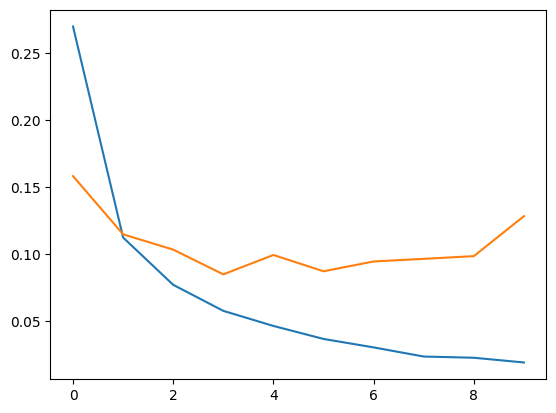

In [28]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

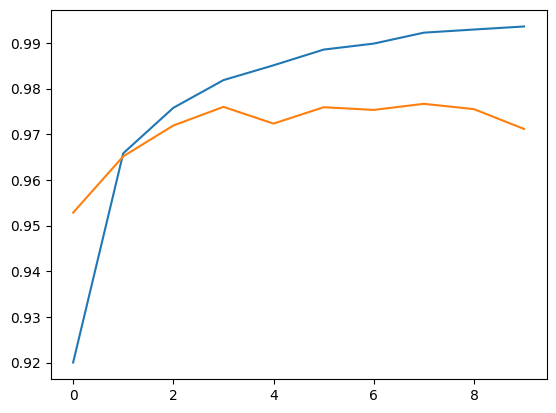

In [29]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


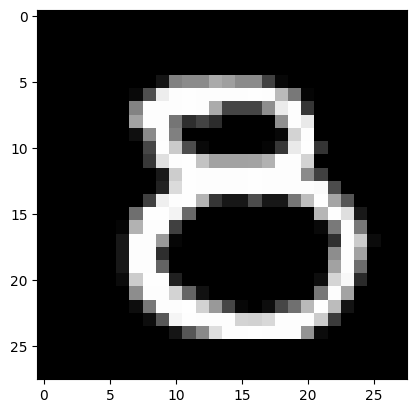

In [30]:
import keras.utils as image

img=image.load_img(path='8.png',color_mode='grayscale',target_size=(28,28))
img=image.img_to_array(img)
plt.imshow(img[:,:,0],cmap='gray')
img=img.astype('float') / 255.0
test_image=img.reshape(1,28,28)
#img_class = model.predict_classes(test_img)
img_class = np.argmax(model.predict(test_image), axis = 1)
prediction=img_class[0]

In [31]:
prediction

np.int64(8)

In [32]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)
accuracy_score(y_pred,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


0.9735

In [33]:
confusion_matrix(y_pred,y_test)

array([[ 966,    0,    5,    0,    1,    2,    2,    1,    0,    1],
       [   0, 1114,    0,    0,    1,    0,    2,    1,    1,    2],
       [   0,    1,  990,    3,    3,    0,    1,    7,    2,    0],
       [   1,    3,    8,  991,    0,   11,    1,    5,    4,    3],
       [   1,    0,    3,    0,  936,    1,    4,    0,    0,    3],
       [   0,    1,    0,    2,    0,  860,    4,    0,    1,    4],
       [   1,    5,    2,    0,    5,    7,  942,    0,    0,    2],
       [   0,    1,    7,    2,    2,    0,    0,  992,    4,    0],
       [   4,   10,   15,    5,    9,    6,    2,    5,  956,    6],
       [   7,    0,    2,    7,   25,    5,    0,   17,    6,  988]])

In [34]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       978
           1       0.98      0.99      0.99      1121
           2       0.96      0.98      0.97      1007
           3       0.98      0.96      0.97      1027
           4       0.95      0.99      0.97       948
           5       0.96      0.99      0.98       872
           6       0.98      0.98      0.98       964
           7       0.96      0.98      0.97      1008
           8       0.98      0.94      0.96      1018
           9       0.98      0.93      0.96      1057

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [35]:
model.save("mnist.hdf5")